Cooling Energy Integration starting with 10 Runs

CSV: /home/aamy/Documents/hfe-system/data/raw/recirculation/log_20260424_153546.csv
Available columns:
['time_s', 'U0_C', 'U1_C', 'TTEST_C', 'TFO_C', 'TTI_C', 'U5_C', 'TTO_C', 'TMI_C', 'THM_C', 'THI_C', 'valve', 'mode', 'pump_cmd_pct', 'pump_freq_hz', 'pump_rotation_speed_rpm', 'pump_input_power_kw', 'pump_input_power_w', 'pump_output_current_a', 'pump_output_voltage_v', 'pump_pressure_before_bar_abs', 'pump_pressure_after_bar_abs', 'pump_pressure_tank_bar_abs', 'pump_pressure_error_bar', 'pump_max_freq_hz', 'fluid_meter_valid', 'fluid_concentration_pct', 'fluid_flow_velocity_mps', 'fluid_volume_flow_m3s', 'fluid_mass_flow_kgs', 'fluid_temperature_c', 'fluid_density_kg_m3', 'fluid_delta_p_bar', 'scale_weight_kg', 'scale_age_s', 'scale_tare_kg']

Valve shutoff times used for C1-C38:
run  t_shutoff_min
 C1       9.343083
 C2      15.339683
 C3      18.163600
 C4      21.022200
 C5      24.334183
 C6      27.576517
 C7      31.027917
 C8      34.340033
 C9      36.641450
C10      40.12778

,cycle,run_number,C_total_J_per_K,C_total_source,t_off_min,T_off_C,t_min_min,T_min_C,deltaT_C,dt_after_off_min,...,sigma_cooling_rate_C_per_min,sigma_cooldown_rate_open_C_per_min,deltaT_THM_LN2_K,cooling_power_open_W,heat_transfer_W_per_K,u_THM_for_G_C,u_deltaT_THM_LN2_K,sigma_cooldown_rate_open_C_per_s,sigma_cooling_power_open_W,sigma_heat_transfer_W_per_K
0,C1,1,770,explicit,9.343083,-89.785739,9.447650,-91.419349,1.633610,0.104567,...,7.849688,0.100620,106.014261,206.465151,1.947522,0.572532,0.574625,0.001677,3.090609,0.031005
1,C2,2,782,explicit,15.339683,-101.943759,15.444283,-102.230878,0.287119,0.104600,...,9.343815,0.274844,93.856241,307.453394,3.275791,0.689706,0.691444,0.004581,5.505950,0.063434
2,C3,3,753,explicit,18.163600,-100.706175,18.442500,-104.191210,3.485035,0.278900,...,3.523230,0.655508,95.093825,435.358693,4.578202,0.677708,0.679477,0.010925,10.135790,0.111494
3,C4,4,718,explicit,21.022200,-101.240811,21.370817,-105.468396,4.227585,0.348617,...,2.854731,0.713691,94.559189,415.327963,4.392254,0.682889,0.684645,0.011895,10.239401,0.112859
4,C5,5,838,explicit,24.334183,-110.893962,24.578217,-112.151347,1.257385,0.244033,...,4.537589,0.610785,84.906038,505.604075,5.954866,0.776830,0.778374,0.010180,10.956917,0.140119
5,C6,6,1018,explicit,27.576517,-110.656346,27.820617,-112.765188,2.108842,0.244100,...,4.547260,0.677413,85.143654,604.335702,7.097836,0.774510,0.776059,0.011290,14.129775,0.178117
6,C7,7,816,explicit,31.027917,-110.992968,31.306817,-114.022573,3.029604,0.278900,...,4.019737,0.630566,84.807032,400.914024,4.727368,0.777797,0.779339,0.010509,10.162266,0.127460
7,C8,8,985,explicit,34.340033,-110.923664,34.724000,-115.507673,4.584009,0.383967,...,2.945962,0.705375,84.876336,445.889072,5.253397,0.777120,0.778664,0.011756,13.071630,0.161373
8,C9,9,997,explicit,36.641450,-119.002608,36.885483,-121.566881,2.564273,0.244033,...,5.035175,0.881120,76.797392,105.268375,1.370729,0.856186,0.857587,0.014685,14.711097,0.192168
9,C10,10,951,explicit,40.127783,-114.002771,41.034333,-122.210424,8.207653,0.906550,...,1.323491,0.860419,81.797229,388.301357,4.747121,0.807214,0.808700,0.014340,14.624398,0.184846


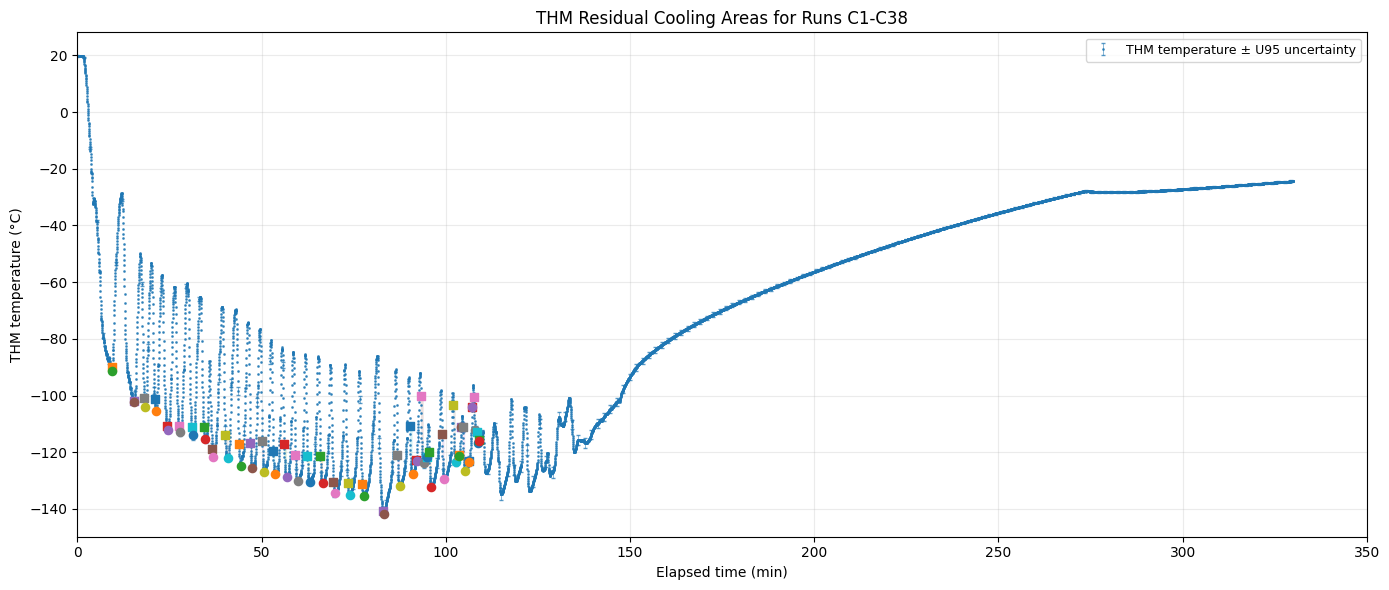

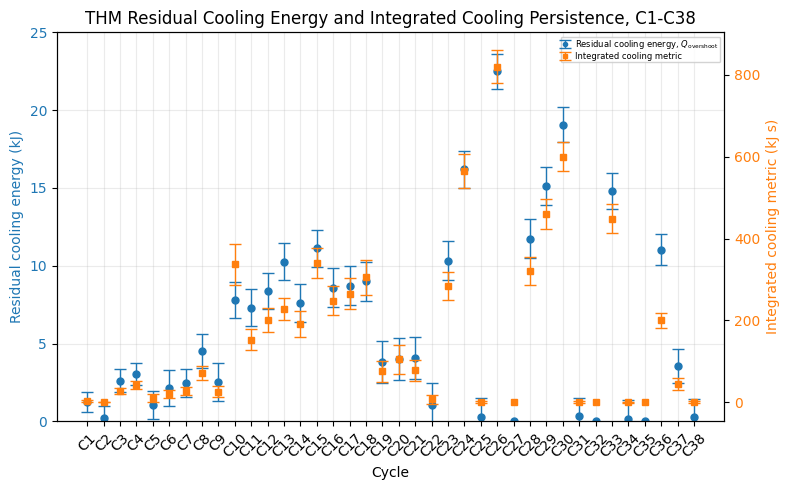

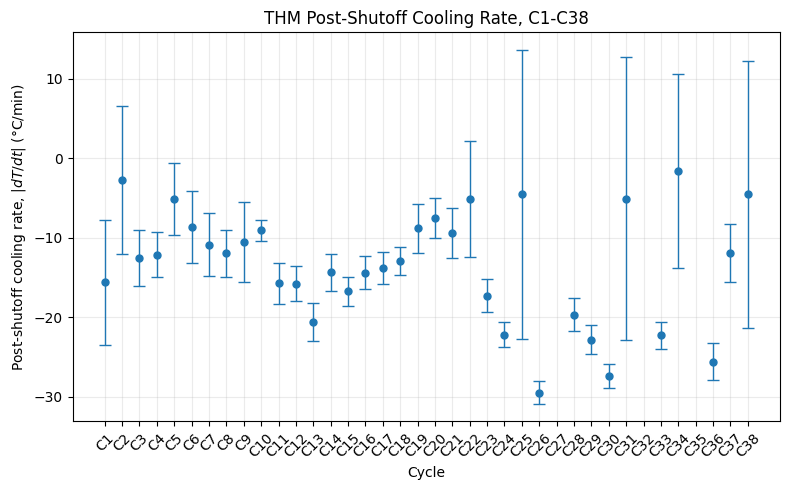

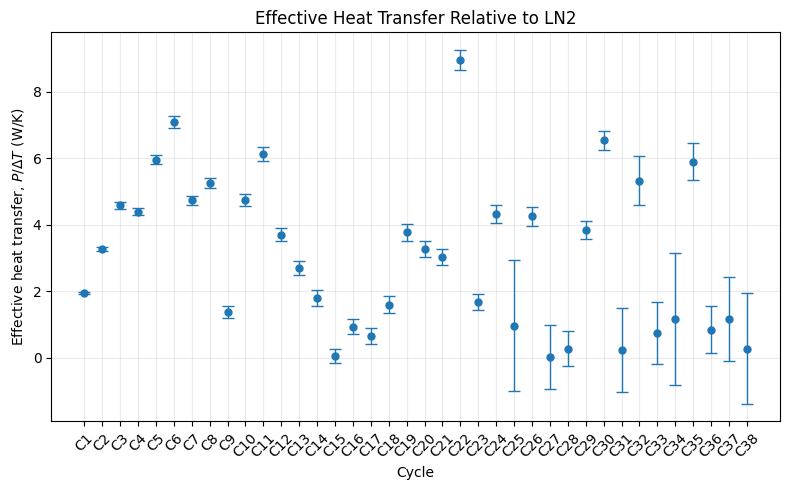

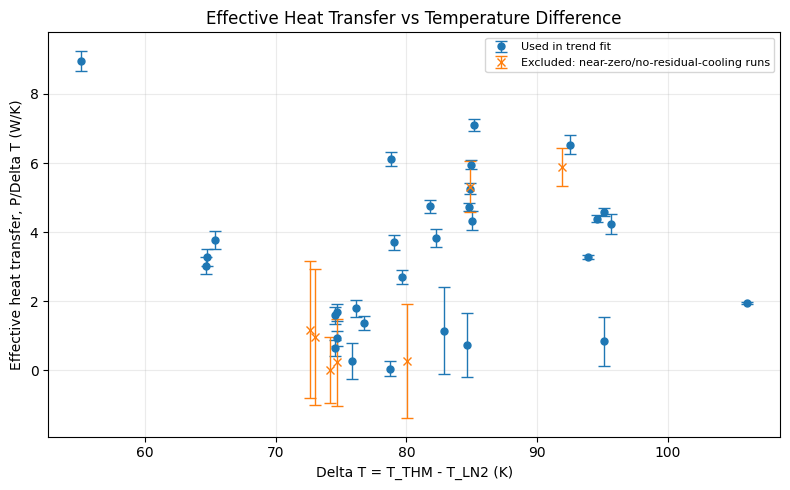

In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid


# ============================================================
# 1. SETTINGS
# ============================================================

C_TOTALS = {
    "C1": 770,
    "C2": 782,
    "C3": 753,
    "C4": 718,
    "C5": 838,
    "C6": 1018,
    "C7": 816,
    "C8": 985,
    "C9": 997,
    "C10": 951,
}

RUN_START = 1
RUN_END = 38

PLOT_START_MIN = 0.0
PLOT_END_MIN = 350.0

DEFAULT_C_TOTAL_J_PER_K = C_TOTALS["C10"]

LN2_TEMP_C = -195.8
U_LN2_C = 0.049

THM_GAIN = 0.990066718500
THM_OFFSET_C = -0.434417973250

U_NOISE_THM_C = 0.0440
U_CAL_THM_C = 0.1617
SIGMA_C_FRAC = 0.0136


# ============================================================
# 2. UNCERTAINTY FUNCTIONS
# ============================================================

def thm_model_uncertainty_C(T_C):
    T_C = np.asarray(T_C, dtype=float)
    return 0.01 * np.maximum(0, -35.04 - T_C)


def thm_cal_uncertainty_C(T_C):
    T_C = np.asarray(T_C, dtype=float)
    return np.full_like(T_C, U_CAL_THM_C)


def thm_instantaneous_uncertainty_C(T_C):
    T_C = np.asarray(T_C, dtype=float)

    u_cal = thm_cal_uncertainty_C(T_C)
    u_noise = U_NOISE_THM_C
    u_model = thm_model_uncertainty_C(T_C)

    return np.sqrt(u_cal**2 + u_noise**2 + u_model**2)


def thm_U95_C(T_C):
    return 2.0 * thm_instantaneous_uncertainty_C(T_C)


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def find_repo_root():
    repo_root = Path.cwd()

    for candidate in [repo_root, *repo_root.parents]:
        if (candidate / "data").exists() and (candidate / "analysis").exists():
            return candidate

    return repo_root


def clean_axes(xlabel, ylabel, title, rotate_xticks=True):
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.25)

    if rotate_xticks:
        plt.xticks(rotation=45)

    plt.tight_layout()


def plot_metric_vs_cycle(y_col, yerr_col, ylabel, title):
    plt.figure(figsize=(8, 5))

    plt.errorbar(
        results_df["cycle"],
        results_df[y_col],
        yerr=results_df[yerr_col],
        fmt="o",
        linestyle="none",
        capsize=4,
        markersize=5,
        elinewidth=1,
    )

    clean_axes(
        xlabel="Cycle",
        ylabel=ylabel,
        title=title,
        rotate_xticks=True
    )

    plt.show()


# ============================================================
# 4. LOAD CSV DATA
# ============================================================

repo_root = find_repo_root()

csv_path = repo_root / "data" / "raw" / "recirculation" / "log_20260424_153546.csv"

if not csv_path.exists():
    csv_path = Path("log_20260424_153546.csv")

df = pd.read_csv(csv_path, comment="#")

print("CSV:", csv_path)
print("Available columns:")
print(df.columns.tolist())


# ============================================================
# 5. CLEAN AND CORRECT DATA
# ============================================================

df["time_s"] = pd.to_numeric(df["time_s"], errors="coerce")
df["THM_C"] = pd.to_numeric(df["THM_C"], errors="coerce")
df["valve"] = pd.to_numeric(df["valve"], errors="coerce")
df["mode"] = df["mode"].astype(str).str.strip().str.upper()

df["THM_corr_C"] = THM_GAIN * df["THM_C"] + THM_OFFSET_C

df["ln_valve_closed"] = (
    df["mode"].eq("C") |
    (df["mode"].eq("A") & df["valve"].eq(0))
)

df["ln_valve_open"] = ~df["ln_valve_closed"]

time_raw = df["time_s"].to_numpy(dtype=float)
T_raw = df["THM_corr_C"].to_numpy(dtype=float)
valve_raw = df["ln_valve_open"].to_numpy()

time_min = (time_raw - time_raw[0]) / 60.0

valid = np.isfinite(time_min) & np.isfinite(T_raw) & pd.notna(valve_raw)

time_min = time_min[valid]
T_raw = T_raw[valid]
valve_raw = valve_raw[valid]

order = np.argsort(time_min)

time_min = time_min[order]
T_raw = T_raw[order]
valve_raw = valve_raw[order]


# ============================================================
# 6. SELECT TIME WINDOW
# ============================================================

window_mask = (time_min >= 0) & (time_min <= 350)

t_run = time_min[window_mask]
T_run = T_raw[window_mask]
valve_run_raw = valve_raw[window_mask]

if len(t_run) == 0:
    raise ValueError("No data points found in the selected time window.")

plot_mask = (t_run >= PLOT_START_MIN) & (t_run <= PLOT_END_MIN)


# ============================================================
# 7. CONVERT VALVE STATE TO BOOLEAN
# ============================================================

if valve_run_raw.dtype == bool:
    valve_open = valve_run_raw
else:
    valve_open = (
        pd.Series(valve_run_raw)
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["1", "true", "open", "o"])
        .to_numpy()
    )


# ============================================================
# 8. FIND VALVE TRANSITIONS
# ============================================================

close_indices_all = np.where(valve_open[:-1] & ~valve_open[1:])[0] + 1
open_indices_all = np.where(~valve_open[:-1] & valve_open[1:])[0] + 1

if len(close_indices_all) == 0:
    raise ValueError("No open-to-closed valve transition found.")

run_numbers_all = np.arange(1, len(close_indices_all) + 1, dtype=int)

selected = (run_numbers_all >= RUN_START) & (run_numbers_all <= RUN_END)

run_numbers = run_numbers_all[selected]
close_indices = close_indices_all[selected]

if len(close_indices) == 0:
    raise ValueError(f"No LN-valve shutoff runs found for C{RUN_START}-C{RUN_END}.")

selected_shutoffs = pd.DataFrame({
    "run": [f"C{run}" for run in run_numbers],
    "t_shutoff_min": t_run[close_indices],
})

print(f"\nValve shutoff times used for C{RUN_START}-C{RUN_END}:")
print(selected_shutoffs.to_string(index=False))

missing_capacity_runs = [
    f"C{run}" for run in run_numbers if f"C{run}" not in C_TOTALS
]

if missing_capacity_runs:
    print(
        "\nUsing DEFAULT_C_TOTAL_J_PER_K = "
        f"{DEFAULT_C_TOTAL_J_PER_K:g} J/K for runs without explicit C_TOTALS: "
        + ", ".join(missing_capacity_runs)
    )


# ============================================================
# 9. CALCULATE LN-VALVE-OPEN COOLDOWN RATES
# ============================================================

open_rate_results = []

for run_number, i_close in zip(run_numbers, close_indices):
    cycle_name = f"C{run_number}"

    if run_number == 1:
        i_start = 0
    else:
        i_start = close_indices_all[run_number - 2]

    open_mask = valve_open[i_start:i_close]

    t_open = t_run[i_start:i_close][open_mask]
    T_open = T_run[i_start:i_close][open_mask]

    if len(t_open) < 2:
        continue

    slope_C_per_min, intercept = np.polyfit(t_open, T_open, 1)

    open_rate_results.append({
        "cycle": cycle_name,
        "t_open_start_min": t_open[0],
        "t_first_close_min": t_run[i_close],
        "T_open_start_C": T_open[0],
        "T_first_close_C": T_run[i_close],
        "cooldown_rate_open_C_per_min": slope_C_per_min,
        "cooldown_rate_open_C_per_s": slope_C_per_min / 60.0,
    })

open_rate_df = pd.DataFrame(open_rate_results)


# ============================================================
# 10. CALCULATE POST-SHUTOFF RESIDUAL COOLING
# ============================================================

results = []

for run_number, i_off in zip(run_numbers, close_indices):
    cycle_name = f"C{run_number}"

    C_TOTAL = C_TOTALS.get(cycle_name, DEFAULT_C_TOTAL_J_PER_K)
    C_TOTAL_source = "explicit" if cycle_name in C_TOTALS else "default"

    next_open = open_indices_all[open_indices_all > i_off]
    i_end = int(next_open[0]) if len(next_open) else len(t_run)

    t_cycle = t_run[i_off:i_end]
    T_cycle = T_run[i_off:i_end]

    if len(t_cycle) < 2:
        continue

    t_off = t_cycle[0]
    T_off = T_cycle[0]

    i_min = np.argmin(T_cycle)

    t_min = t_cycle[i_min]
    T_min = T_cycle[i_min]

    t_section = t_cycle[:i_min + 1]
    T_section = T_cycle[:i_min + 1]

    residual_area_C_min = trapezoid(T_off - T_section, t_section)

    deltaT_C = T_off - T_min

    Q_overshoot_J = C_TOTAL * deltaT_C
    integrated_metric_J_s = C_TOTAL * residual_area_C_min * 60.0

    dt_after_off_min = t_min - t_off
    dt_after_off_s = dt_after_off_min * 60.0

    if dt_after_off_min == 0:
        cooling_rate_C_per_min = np.nan
        cooling_rate_C_per_s = np.nan
    else:
        cooling_rate_C_per_min = (T_min - T_off) / dt_after_off_min
        cooling_rate_C_per_s = cooling_rate_C_per_min / 60.0

    results.append({
        "cycle": cycle_name,
        "run_number": run_number,
        "C_total_J_per_K": C_TOTAL,
        "C_total_source": C_TOTAL_source,
        "t_off_min": t_off,
        "T_off_C": T_off,
        "t_min_min": t_min,
        "T_min_C": T_min,
        "deltaT_C": deltaT_C,
        "dt_after_off_min": dt_after_off_min,
        "dt_after_off_s": dt_after_off_s,
        "cooling_rate_C_per_min": cooling_rate_C_per_min,
        "cooling_rate_C_per_s": cooling_rate_C_per_s,
        "area_C_min": residual_area_C_min,
        "Q_overshoot_kJ": Q_overshoot_J / 1000.0,
        "integrated_metric_kJ_s": integrated_metric_J_s / 1000.0,
        "u_T_off_C": float(thm_instantaneous_uncertainty_C(T_off)),
        "u_T_min_C": float(thm_instantaneous_uncertainty_C(T_min)),
        "U95_T_off_C": float(thm_U95_C(T_off)),
        "U95_T_min_C": float(thm_U95_C(T_min)),
    })

results_df = pd.DataFrame(results)

results_df = results_df.merge(open_rate_df, on="cycle", how="left")


# ============================================================
# 11. UNCERTAINTY CALCULATIONS
# ============================================================

results_df["sigma_deltaT_C"] = np.sqrt(
    results_df["u_T_off_C"]**2 +
    results_df["u_T_min_C"]**2
)

results_df["sigma_C_total_J_per_K"] = (
    SIGMA_C_FRAC * results_df["C_total_J_per_K"]
)

relative_uncertainty = np.sqrt(
    (results_df["sigma_C_total_J_per_K"] / results_df["C_total_J_per_K"])**2
    +
    (results_df["sigma_deltaT_C"] / results_df["deltaT_C"].abs())**2
)

results_df["sigma_Q_overshoot_kJ"] = (
    results_df["Q_overshoot_kJ"].abs() * relative_uncertainty
)

results_df["sigma_integrated_metric_kJ_s"] = (
    results_df["integrated_metric_kJ_s"].abs() * relative_uncertainty
)

results_df["sigma_cooling_rate_C_per_min"] = (
    results_df["sigma_deltaT_C"] /
    results_df["dt_after_off_min"].replace(0, np.nan)
)

results_df["sigma_cooldown_rate_open_C_per_min"] = (
    results_df["sigma_deltaT_C"] /
    (
        results_df["t_first_close_min"] -
        results_df["t_open_start_min"]
    ).replace(0, np.nan)
)


# ============================================================
# 12. EFFECTIVE HEAT TRANSFER CALCULATION
# ============================================================

results_df["deltaT_THM_LN2_K"] = (
    results_df["T_first_close_C"] - LN2_TEMP_C
)

results_df["cooling_power_open_W"] = (
    results_df["C_total_J_per_K"] *
    results_df["cooldown_rate_open_C_per_s"].abs()
)

results_df["heat_transfer_W_per_K"] = (
    results_df["cooling_power_open_W"] /
    results_df["deltaT_THM_LN2_K"]
)

results_df["u_THM_for_G_C"] = results_df["T_first_close_C"].apply(
    lambda T_val: float(thm_instantaneous_uncertainty_C(T_val))
)

results_df["u_deltaT_THM_LN2_K"] = np.sqrt(
    results_df["u_THM_for_G_C"]**2 + U_LN2_C**2
)

results_df["sigma_cooldown_rate_open_C_per_s"] = (
    results_df["sigma_cooldown_rate_open_C_per_min"] / 60.0
)

results_df["sigma_cooling_power_open_W"] = (
    results_df["cooling_power_open_W"].abs()
    *
    np.sqrt(
        (results_df["sigma_C_total_J_per_K"] / results_df["C_total_J_per_K"])**2
        +
        (
            results_df["sigma_cooldown_rate_open_C_per_s"] /
            results_df["cooldown_rate_open_C_per_s"].abs()
        )**2
    )
)

results_df["sigma_heat_transfer_W_per_K"] = (
    results_df["heat_transfer_W_per_K"].abs()
    *
    np.sqrt(
        (
            results_df["sigma_cooling_power_open_W"] /
            results_df["cooling_power_open_W"].abs()
        )**2
        +
        (
            results_df["u_deltaT_THM_LN2_K"] /
            results_df["deltaT_THM_LN2_K"]
        )**2
    )
)


# ============================================================
# 13. PRINT TABLE
# ============================================================

print("\nFinal results table:")
print(results_df.to_string(index=False))

try:
    display(results_df)
except NameError:
    pass

# ============================================================
# 13B. DEFINE GOOD RUNS FOR HEAT TRANSFER TREND FITS
# ============================================================

bad_heat_transfer_cycles = ["C25", "C27", "C31", "C32", "C34", "C35", "C38"]

fit_df = results_df[
    ~results_df["cycle"].isin(bad_heat_transfer_cycles)
].copy()

# ============================================================
# 14. PLOT: THM TEMPERATURE WITH RESIDUAL COOLING AREAS
# ============================================================

plt.figure(figsize=(14, 6))

plt.errorbar(
    t_run[plot_mask],
    T_run[plot_mask],
    yerr=thm_U95_C(T_run[plot_mask]),
    fmt=".",
    linestyle="none",
    markersize=2,
    elinewidth=0.5,
    capsize=1.5,
    errorevery=50,
    alpha=0.75,
    label="THM temperature ± U95 uncertainty"
)

for _, row in results_df.iterrows():
    t_off = row["t_off_min"]
    t_min = row["t_min_min"]
    T_off = row["T_off_C"]

    shade_mask = (t_run >= t_off) & (t_run <= t_min)

    plt.fill_between(
        t_run[shade_mask],
        T_run[shade_mask],
        T_off,
        alpha=0.18
    )

    plt.scatter(
        t_off,
        T_off,
        marker="s",
        s=35,
        zorder=5
    )

    plt.scatter(
        t_min,
        row["T_min_C"],
        marker="o",
        s=35,
        zorder=5
    )

plt.xlim(PLOT_START_MIN, PLOT_END_MIN)

clean_axes(
    xlabel="Elapsed time (min)",
    ylabel="THM temperature (°C)",
    title=f"THM Residual Cooling Areas for Runs C{RUN_START}-C{RUN_END}",
    rotate_xticks=False
)

plt.legend(fontsize=9)
plt.show()


# ============================================================
# 15. CLEAN SUMMARY PLOTS
# ============================================================

fig, ax_energy = plt.subplots(figsize=(8, 5))

energy_color = "tab:blue"
metric_color = "tab:orange"

ax_energy.errorbar(
    results_df["cycle"],
    results_df["Q_overshoot_kJ"],
    yerr=results_df["sigma_Q_overshoot_kJ"],
    fmt="o",
    linestyle="none",
    capsize=4,
    markersize=5,
    elinewidth=1,
    color=energy_color,
    ecolor=energy_color,
    label=r"Residual cooling energy, $Q_{\mathrm{overshoot}}$"
)

ax_energy.set_xlabel("Cycle")
ax_energy.set_ylabel("Residual cooling energy (kJ)", color=energy_color)
ax_energy.set_ylim(0, 25)
ax_energy.tick_params(axis="y", labelcolor=energy_color)
ax_energy.tick_params(axis="x", rotation=45)
ax_energy.grid(True, alpha=0.25)

ax_metric = ax_energy.twinx()
ax_metric.errorbar(
    results_df["cycle"],
    results_df["integrated_metric_kJ_s"],
    yerr=results_df["sigma_integrated_metric_kJ_s"],
    fmt="s",
    linestyle="none",
    capsize=4,
    markersize=5,
    elinewidth=1,
    color=metric_color,
    ecolor=metric_color,
    label="Integrated cooling metric"
)
ax_metric.set_ylabel("Integrated cooling metric (kJ s)", color=metric_color)
ax_metric.tick_params(axis="y", labelcolor=metric_color)

lines_energy, labels_energy = ax_energy.get_legend_handles_labels()
lines_metric, labels_metric = ax_metric.get_legend_handles_labels()
ax_energy.legend(
    lines_energy + lines_metric,
    labels_energy + labels_metric,
    loc="upper right",
    fontsize=6,
    markerscale=0.6,
    handlelength=0.8,
    borderpad=0.15,
    labelspacing=0.15,
    framealpha=0.85
)

plt.title(
    f"THM Residual Cooling Energy and Integrated Cooling Persistence, C{RUN_START}-C{RUN_END}"
)
fig.tight_layout()
plt.show()

plot_metric_vs_cycle(
    y_col="cooling_rate_C_per_min",
    yerr_col="sigma_cooling_rate_C_per_min",
    ylabel=r"Post-shutoff cooling rate, $|dT/dt|$ (°C/min)",
    title=f"THM Post-Shutoff Cooling Rate, C{RUN_START}-C{RUN_END}"
)

plot_metric_vs_cycle(
    y_col="heat_transfer_W_per_K",
    yerr_col="sigma_heat_transfer_W_per_K",
    ylabel=r"Effective heat transfer, $P/\Delta T$ (W/K)",
    title="Effective Heat Transfer Relative to LN2"
)

# ============================================================
# 16. PLOT: HEAT TRANSFER VS DELTA T, WITH QUESTIONABLE RUNS REMOVED
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    fit_df["deltaT_THM_LN2_K"],
    fit_df["heat_transfer_W_per_K"],
    yerr=fit_df["sigma_heat_transfer_W_per_K"],
    fmt="o",
    linestyle="none",
    capsize=4,
    markersize=5,
    elinewidth=1,
    label="Used in trend fit"
)

# Optional: show removed points separately
removed_df = results_df[results_df["cycle"].isin(bad_heat_transfer_cycles)]

plt.errorbar(
    removed_df["deltaT_THM_LN2_K"],
    removed_df["heat_transfer_W_per_K"],
    yerr=removed_df["sigma_heat_transfer_W_per_K"],
    fmt="x",
    linestyle="none",
    capsize=4,
    markersize=6,
    elinewidth=1,
    label="Excluded: near-zero/no-residual-cooling runs"
)

clean_axes(
    xlabel="Delta T = T_THM - T_LN2 (K)",
    ylabel="Effective heat transfer, P/Delta T (W/K)",
    title="Effective Heat Transfer vs Temperature Difference",
    rotate_xticks=False
)

plt.legend(fontsize=8)
plt.show()

Residual Cooling Energy After LN Valve Shutoff:
The residual cooling energy Q overshoot measures how much cooling remains in the system after the LN valve is shut off. After the LN stops flowing, the heat exchanger (HX) continues cooling for a short time because cold energy is still stored in the system. Cycles C1–C7 have residual cooling energies between about 6–9 kJ, showing that the HX continues cooling significantly after the nitrogen flow stops. The largest value occurs during C6, where the HX cooled from -121.25°C at valve shutoff to -130.41°C at its minimum temperature, a drop of 9.16°C.Using the heat capacity of 1018 J/K, you get a Q overshoot of about 9.3kJ. In contrast, cycles C8–C10 drop to about 4 kJ, indicating that much less cooling remains available after valve shutoff in the later cycles.

Integrated Persistance:
This plot measures not only how far the temperature drops after valve shutoff, but also how long the cooling continues. Larger values indicate that the HX stayed colder for a longer period of time. The largest values occur during C4–C7, meaning these cycles experienced the strongest and longest-lasting residual cooling. Cycles C8–C10 are much lower, indicating that the remaining cooling effect after valve shutoff is significantly reduced.

Shaded Integral Regions:
The shaded regions represent the exact area that was integrated for each cycle. Each shaded area begins when the LN valve is closed and ends when the HX reaches its minimum temperature. A larger shaded area means larger temperature drop after shutoff, longer cooling duration after shutoff, and therefore a stronger residual cooling effect. The largest shaded regions occur in C4–C7, while C8–C10 have much smaller shaded regions, matching the trends seen in both the residual cooling energy and integrated cooling persistence plots.

Effective Heat Transfer vs Temp Diff:
For the heat transfer trend analysis, cycles C25, C27, C31, C32, C34, C35, and C38 were excluded because they showed little or no residual cooling after the LN valve was shut off. In these runs, the temperature drop after shutoff was very small (typically less than 0.4 °C), making the calculated cooling rates highly sensitive to measurement uncertainty. As a result, the heat transfer values from these cycles were not representative of the overall cooling behavior of the system. These runs were excluded from the trend fit but retained in the full dataset for completeness. 
The error bars on the effective heat transfer were calculated using standard uncertainty propagation. They include contributions from the uncertainty in the effective heat capacity, the cooldown rate, the THM temperature measurement, and the LN₂ temperature. The uncertainty in the cooldown rate was determined from the scatter of the temperature data around the linear fit during the LN-valve-open period. This uses all available temperature measurements and provides a better estimate of the uncertainty than using only the start and end temperatures. Overall, the error bars represent the combined uncertainty in all quantities used to calculate the effective heat transfer coefficient.



Overall Trend:
All three plots show that the HX continues cooling after the LN valve is shut off because stored cold energy remains in the system. Cycles C1–C7 show stronger residual cooling, with larger temperature drops, larger integrated areas, and higher residual cooling energies. Beginning around C8, all three quantities decrease substantially, suggesting that less stored cooling remains available after valve shutoff during the later cycles.
